In [2]:
import numpy as np
import pandas as pd
from scipy.integrate import odeint
import matplotlib.pyplot as plt

In [15]:
# Constants
M_sun = 2e33             # Solar mass in g
M_tot = 0.01 * M_sun     # Total mass of the ejecta in g
c = 3e10                 # Speed of light in cm/s
v_min = 0.1 * c          # Minimum velocity of massive shell in cm/s
beta = 3                 # factor for homologous expansion - ensures shells never overlap 
numshells = 10           # Number of shells

#Time array
t = np.logspace(0, 6, 1000)              
# Velocity array for each shell
v_shells = np.linspace(0.1, 1, numshells)* c

# Mass distribution
M_shells = beta * M_tot * (v_min**(beta)) * (v_shells**(-beta-1))    # Mass fraction based on velocity
M_shells = M_shells * M_tot / np.sum(M_shells)                       # Normalised so the shells sum to M_0
E_int_shells =  0.5 * M_shells * (v_shells**2)                     # Internal energy per shell, assming kinetic energy is similar to internal energy

#Dataframe of properties
shell_data = pd.DataFrame({'Velocity (cm/s)': v_shells, 'Mass (g)': M_shells, 'Internal Energy (erg)': E_int_shells})

# Constants associated with heating and radiative loss terms
av = 0.56
bv = 0.71
cv = 0.74
xr = 0.6
kv = [20, 5, 1]                  # Opacity ranges for kilonova colors

# Heating efficiency as a function of time
def eps_th_v(t):
    t_day = t / 86400  # Convert seconds to days
    exp_term = np.exp(-av * t_day)
    log_term = np.log(1 + 2 * bv * t_day**cv)
    result = 0.36 * (exp_term + (log_term / (2 * bv * t_day**cv)))
    return result

# R-process energy deposition rate
def e_dot_r(t):
    t0 = 1.3  
    sigma = 0.11  
    arctan_term = np.arctan((t - t0) / sigma)
    result = 4e18 * eps_th_v(t) * (0.5 - (1 / np.pi) * arctan_term)**1.3
    return result

# Heating due to radioactive decay
def Q_rv(Mv, t):
    return Mv * xr * e_dot_r(t)

# Diffusion time
def t_diff(M_shells, t):
    return ((M_shells**(4./3.)) * kv[2]) / (4 * np.pi * (M_tot**(1./3.)) * v_min * t * c)

# Radiative losses
def L_v(R, Eint, t_diff):
    t_lc = (R / c)                            # Light-crossing time
    return Eint / (t_diff + t_lc)

# ODEs governing energy and dynamics
def energy(y, t, M):
    Eint, R, v = y
    diff_time = t_diff(M, t)
    dEint = -((Eint / R) * v) + Q_rv(M, t) - L_v(R, Eint, diff_time)
    dR = v
    dv = Eint / (M * R)
    return [dEint, dR, dv]
# Solving for each shell
E_all = []
R_all = []
v_all = []
t_peak = []
lv_values = []
for i, row in shell_data.iterrows():
    M = row['Mass (g)']
    Eint0 = row['Internal Energy (erg)']
    v0 = row['Velocity (cm/s)']
    R0 = 1e9  # Initial radius
    y0 = [Eint0, R0, v0]
    Edep = odeint(energy, y0, t, args=(M,))
    E_all.append(Edep[:, 0])  
    R_all.append(Edep[:, 1])  
    v_all.append(Edep[:, 2])
    t_peak.append(t_diff(M,t))
    lv_values.append(L_v(R0,Eint0,t_diff(M,t))) 
lv_values = np.array(lv_values)
print(lv_values.shape)  

(10, 1000)


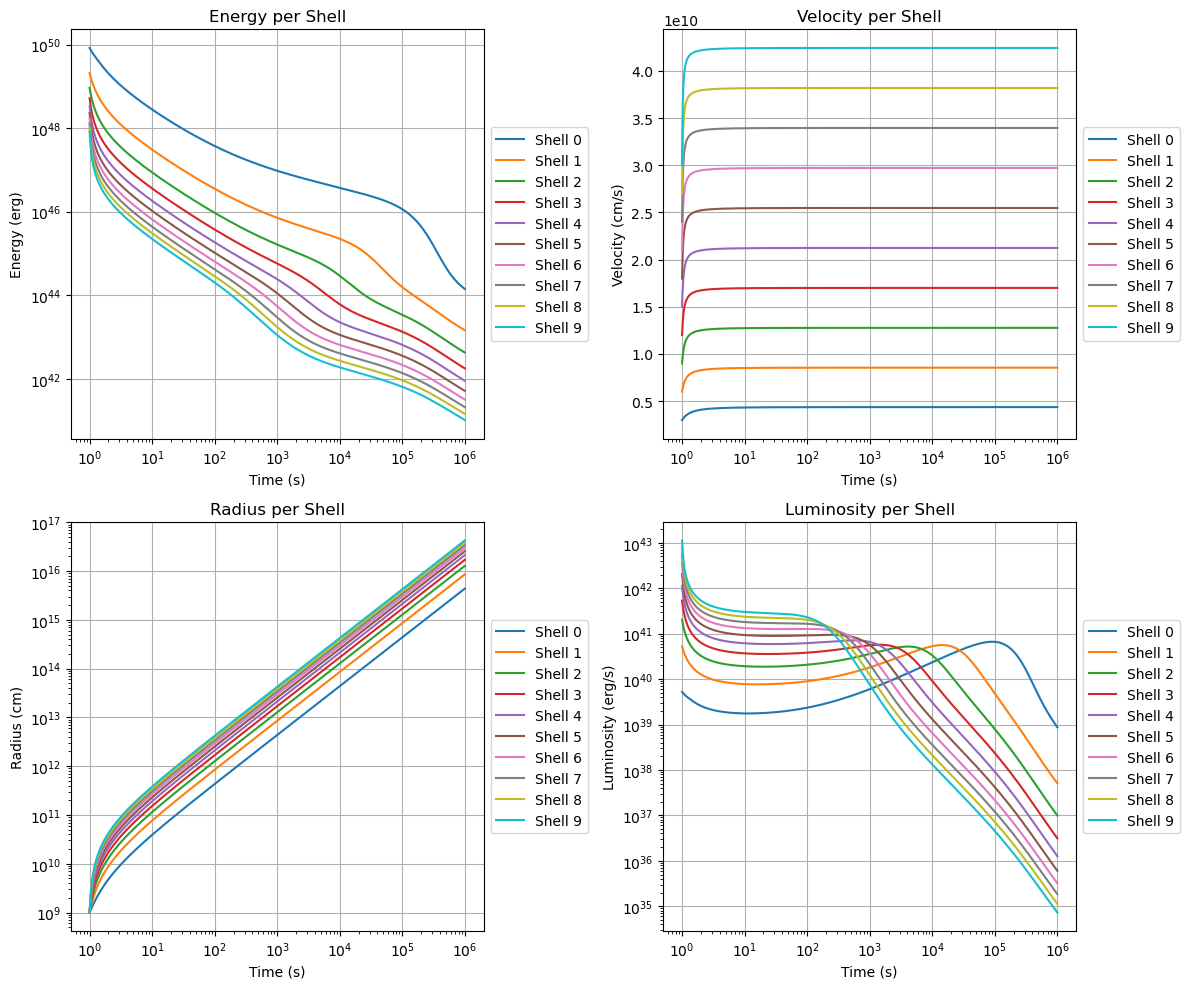

In [16]:

plt.figure(figsize=(12, 10))

# Energy per shell
plt.subplot(2, 2, 1)
for i, E in enumerate(E_all):
    plt.loglog(t, E, label=f'Shell {i}')
plt.xlabel('Time (s)')
plt.ylabel('Energy (erg)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('Energy per Shell')
plt.grid(True)

# Velocity per shell
plt.subplot(2, 2, 2)
for i, v in enumerate(v_all):
    plt.plot(t, v, label=f'Shell {i}')
plt.xscale('log')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (cm/s)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('Velocity per Shell')
plt.grid(True)

# Radius per shell
plt.subplot(2, 2, 3)
for i, R in enumerate(R_all):
    plt.loglog(t, R, label=f'Shell {i}')
plt.xlabel('Time (s)')
plt.ylabel('Radius (cm)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('Radius per Shell')
plt.grid(True)

# Luminosity per shell
plt.subplot(2, 2, 4)
for i, (R, Eint) in enumerate(zip(R_all, E_all)):
    lv_plot = L_v(R, Eint, t_diff(shell_data['Mass (g)'][i], t))
    plt.loglog(t, lv_plot, label=f'Shell {i}')
plt.xlabel('Time (s)')
plt.ylabel('Luminosity (erg/s)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('Luminosity per Shell')
plt.grid(True)

plt.tight_layout()
plt.show()

For each mass shell, sum the values of the optical depth until it equals 1. Then select the value of the R_v when this conidition is met.

In [17]:
t_peak = np.array(t_peak)
print(t_peak.shape)

(10, 1000)


M_all shape: (10,)
R_all shape: (10, 1000)
[1.00000000e+09 1.45181899e+09 1.95428015e+09 2.48849128e+09
 3.04567932e+09 3.62122563e+09 4.21246547e+09 4.81775794e+09
 5.43604567e+09 6.06662654e+09 6.70902661e+09 7.36292502e+09
 8.02810749e+09 8.70443631e+09 9.39183031e+09 1.00902511e+10
 1.07996934e+10 1.15201779e+10 1.22517464e+10 1.29944579e+10
 1.37483853e+10 1.45136138e+10 1.52902387e+10 1.60783643e+10
 1.68781027e+10 1.76895729e+10 1.85129003e+10 1.93482157e+10
 2.01956556e+10 2.10553610e+10 2.19274776e+10 2.28121553e+10
 2.37095484e+10 2.46198146e+10 2.55431159e+10 2.64796176e+10
 2.74294887e+10 2.83929016e+10 2.93700322e+10 3.03610597e+10
 3.13661667e+10 3.23855389e+10 3.34193655e+10 3.44678388e+10
 3.55311544e+10 3.66095111e+10 3.77031110e+10 3.88121594e+10
 3.99368649e+10 4.10774393e+10 4.22340979e+10 4.34070590e+10
 4.45965445e+10 4.58027795e+10 4.70259926e+10 4.82664157e+10
 4.95242843e+10 5.07998372e+10 5.20933170e+10 5.34049695e+10
 5.47350444e+10 5.60837948e+10 5.74514776e

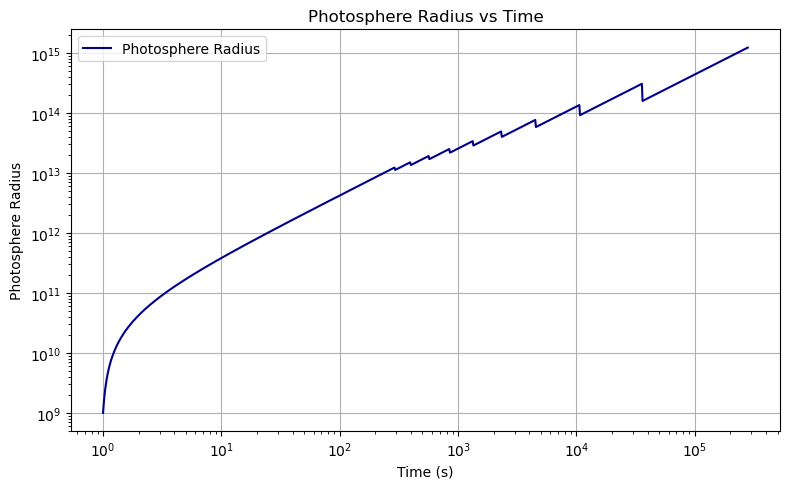

In [24]:
M_all = np.array(shell_data['Mass (g)']).squeeze() 
R_all = np.array(R_all)  

print("M_all shape:", M_all.shape)  
print("R_all shape:", R_all.shape)  

def tau_contribution(M, R):
    return (kv[2] * M) / (4 * np.pi * (R**2))

R_ph_ns = np.full((1000,), np.nan)  # Initialize R_ph with NaNs
j_index = np.zeros(1000, dtype=int)  # Store the last used j value for each column

i = R_all.shape[0] - 1  # Start from the last mass layer
while i >= 0:  # Loop over mass layers from outer to inner
    j = j_index[0]  # Start from the last used j for all columns
    while j < R_all.shape[1]:  # Loop over radii
        tau = tau_contribution(M_all[i], R_all[i, j])
        
        if np.isnan(R_ph_ns[j]):  # Assign if R_ph[j] is still NaN
            R_ph_ns[j] = R_all[i, j]

        if tau <= 1:  
            j_index[:] = j  # Store the current j for the next iteration of i
            break  # Break out of j loop, but keep this j for next i

        j += 1  # Move to the next radius in the same layer

    i -= 1  # Move to the next mass layer
print(R_ph_ns)
print(R_ph_ns.shape) 

plt.figure(figsize=(8, 5))
plt.loglog(t, R_ph_ns, label='Photosphere Radius', color='darkblue') 
plt.xlabel('Time (s)')
plt.ylabel('Photosphere Radius')
plt.title('Photosphere Radius vs Time')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


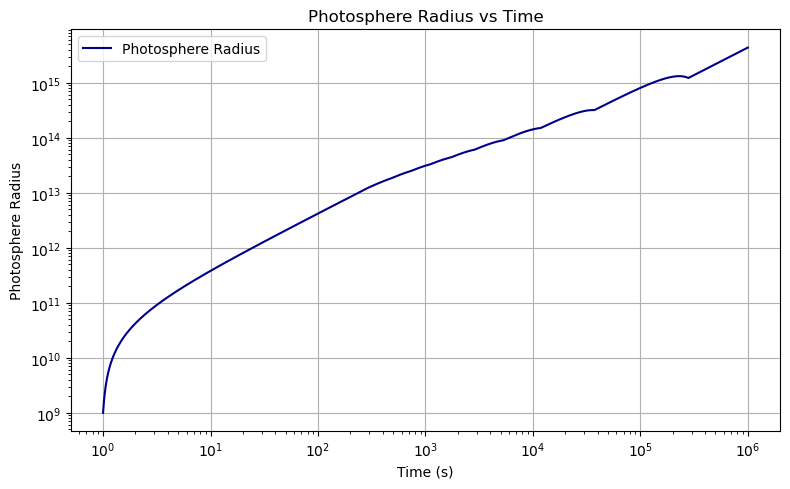

In [25]:
from scipy.ndimage import gaussian_filter1d
M_all = np.array(shell_data['Mass (g)']).squeeze() 
R_all = np.array(R_all)  

def compute_photosphere_radius(R_all, shell_masses, t):

    num_shells, num_times = R_all.shape
    R_ph = np.zeros(num_times)
    
    for i in range(num_times):
       
        tau_cumu = 0.0
        tau_list = []
        R_list = []
    
        for j in range(num_shells - 1, -1, -1):
            R_curr = R_all[j, i]
      
          
            d_tau = kv[2] * shell_masses[j] / (4 * np.pi * R_curr**2)
          
            tau_cumu += d_tau
            tau_list.append(tau_cumu)
            R_list.append(R_curr)
    
        tau_array = np.array(tau_list)
        
        R_array = np.array(R_list)
    
       
        if tau_array[-1] < 1:
            R_ph[i] = R_array[-1]
        else:
            indices = np.where(tau_array >= 1)[0]
            idx = indices[0]
            if idx == 0:
                R_ph[i] = R_array[0]
            else:
                
                tau_low = tau_array[idx - 1]
                tau_high = tau_array[idx]
                R_low = R_array[idx - 1]
                R_high = R_array[idx]
                f = (1 - tau_low) / (tau_high - tau_low)
                R_ph[i] = R_low + f * (R_high - R_low)
                
    
    return R_ph
R_ph = compute_photosphere_radius(R_all, M_shells, t)

plt.figure(figsize=(8, 5))
plt.loglog(t, R_ph, label='Photosphere Radius', color='darkblue') 
plt.xlabel('Time (s)')
plt.ylabel('Photosphere Radius')
plt.title('Photosphere Radius vs Time')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

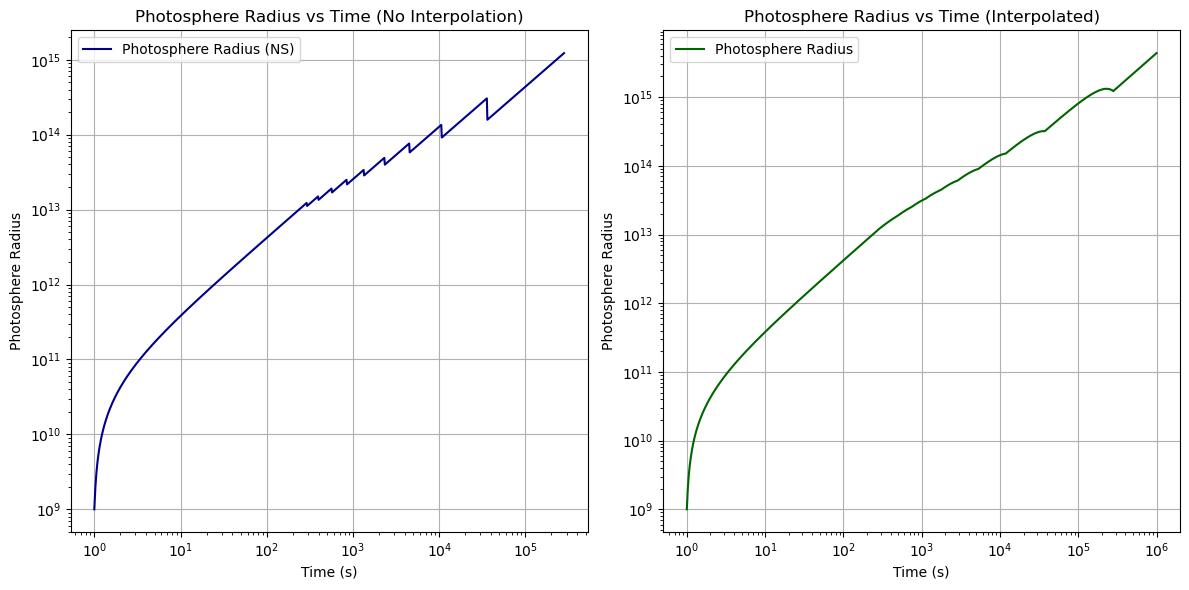

In [30]:

plt.figure(figsize=(12, 6))  # Wider aspect ratio for side-by-side plots

# Left plot
plt.subplot(1, 2, 1)
plt.loglog(t, R_ph_ns, label='Photosphere Radius (NS)', color='darkblue')
plt.xlabel('Time (s)')
plt.ylabel('Photosphere Radius')
plt.title('Photosphere Radius vs Time (No Interpolation)')
plt.grid(True)
plt.legend()

# Right plot
plt.subplot(1, 2, 2)
plt.loglog(t, R_ph, label='Photosphere Radius', color='darkgreen')
plt.xlabel('Time (s)')
plt.ylabel('Photosphere Radius')
plt.title('Photosphere Radius vs Time (Interpolated)')
plt.grid(True)
plt.legend()

# Finalize layout and show both
plt.tight_layout()
plt.show()


In [8]:
L_tot = np.sum([L_v(R, Eint, t_diff(shell_data['Mass (g)'][i], t)) 
                for i, (R, Eint) in enumerate(zip(R_all, E_all))], axis=0)

sigma = 5.67e-5    # Stefan's constant in erg / cm^2 / s / K^4
h = 6.626e-27      # Planck's constant in erg * s
nu = 5e15          # Frequency (Hz), can be altered to see fluxes of different frequencies
kB = 1.38e-16      # Boltzmann's constant in erg / K
D = 1e25           # Luminosity distance in cm, as used by Metzger in his paper (100 Mpc)

T_eff = (L_tot / (4 * np.pi * sigma * (R_ph**2)))**(1/4)

exponent = (h * nu) / (kB * T_eff)
print(exponent)

[1.65018158e-02 1.97903098e-02 2.31416751e-02 2.64875539e-02
 2.98003843e-02 3.30696312e-02 3.62922090e-02 3.94683801e-02
 4.25998994e-02 4.56891373e-02 4.87386562e-02 5.17510047e-02
 5.47286208e-02 5.76737908e-02 6.05886365e-02 6.34751169e-02
 6.63350374e-02 6.91700622e-02 7.19817277e-02 7.47714555e-02
 7.75405664e-02 8.02902917e-02 8.30217850e-02 8.57361321e-02
 8.84343593e-02 9.11174410e-02 9.37863033e-02 9.64418265e-02
 9.90848449e-02 1.01716144e-01 1.04336458e-01 1.06946469e-01
 1.09546807e-01 1.12138049e-01 1.14720733e-01 1.17295353e-01
 1.19862372e-01 1.22422225e-01 1.24975321e-01 1.27522049e-01
 1.30062779e-01 1.32597864e-01 1.35127644e-01 1.37652442e-01
 1.40172572e-01 1.42688332e-01 1.45200012e-01 1.47707891e-01
 1.50212237e-01 1.52713309e-01 1.55211358e-01 1.57706627e-01
 1.60199349e-01 1.62689752e-01 1.65178056e-01 1.67664474e-01
 1.70149214e-01 1.72632475e-01 1.75114454e-01 1.77595339e-01
 1.80075317e-01 1.82554566e-01 1.85033261e-01 1.87511574e-01
 1.89989670e-01 1.924677

[2.78015368e-34 4.87816679e-34 7.54627798e-34 1.06722205e-33
 1.41856138e-33 1.80413836e-33 2.22097417e-33 2.66704782e-33
 3.14096517e-33 3.64175991e-33 4.16876889e-33 4.72155128e-33
 5.29983411e-33 5.90347465e-33 6.53243360e-33 7.18675560e-33
 7.86655471e-33 8.57200334e-33 9.30332375e-33 1.00607813e-32
 1.08446788e-32 1.16553525e-32 1.24931681e-32 1.33585175e-32
 1.42518165e-32 1.51735027e-32 1.61240339e-32 1.71038876e-32
 1.81135604e-32 1.91535686e-32 2.02244493e-32 2.13267608e-32
 2.24610839e-32 2.36280214e-32 2.48281984e-32 2.60622619e-32
 2.73308798e-32 2.86347410e-32 2.99745542e-32 3.13510486e-32
 3.27649729e-32 3.42170957e-32 3.57082056e-32 3.72391109e-32
 3.88106402e-32 4.04236427e-32 4.20789878e-32 4.37775662e-32
 4.55202895e-32 4.73080910e-32 4.91419257e-32 5.10227712e-32
 5.29516273e-32 5.49295170e-32 5.69574867e-32 5.90366064e-32
 6.11679707e-32 6.33526986e-32 6.55919344e-32 6.78868479e-32
 7.02386352e-32 7.26485188e-32 7.51177485e-32 7.76476017e-32
 8.02393838e-32 8.289442

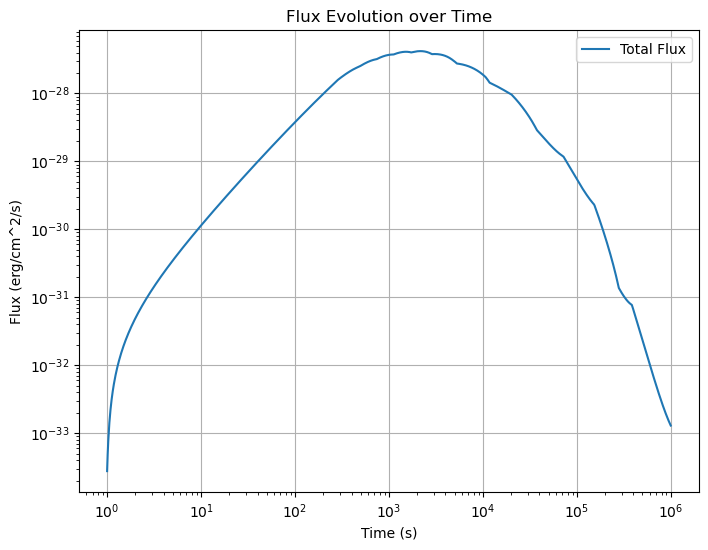

In [31]:
D = 1e26
Flux = ((2 * np.pi * h * (nu**3)) / (c**2)) * (1 / (np.exp(exponent) - 1)) * (R_ph**2 / D**2)
print(Flux)
Flux = np.array(Flux)
print(Flux)
# Plotting the flux
plt.figure(figsize=(8, 6))
plt.loglog(t, Flux, label='Total Flux')  # Plot the total flux (sum of all shells)
plt.xlabel('Time (s)')
plt.ylabel('Flux (erg/cm^2/s)')
plt.title('Flux Evolution over Time')
plt.grid(True)
plt.legend()
plt.show()

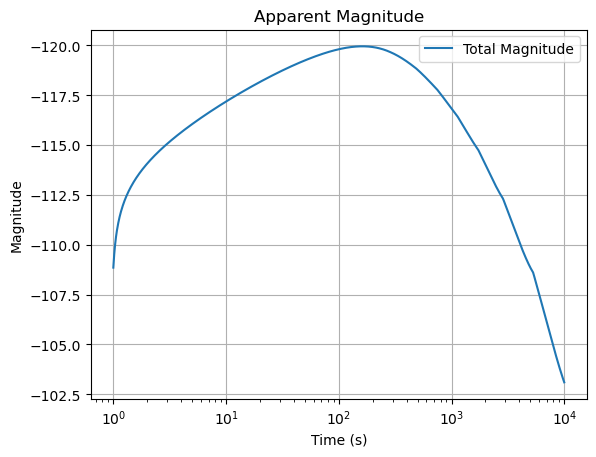

In [10]:
zero_point_flux = 1e-23
plt.subplot(1, 1, 1)
total_magnitude = -2.5 * np.log10(Flux / zero_point_flux)
plt.plot(t, total_magnitude, label='Total Magnitude')
plt.xscale('log')
ax = plt.gca()
#ax.set_xlim([0, 1e3])
#ax.set_ylim([12, 25])
plt.xlabel('Time (s)')
plt.gca().invert_yaxis()
plt.ylabel('Magnitude')
plt.legend()
plt.title('Apparent Magnitude')
plt.grid(True)

from scipy.ndimage import gaussian_filter1d

# Initialise R_ph full of nans
R_ph = np.full((R_all.shape[1],), np.nan)

# Start from the outermost shell 
i = R_all.shape[0] - 1  # Start from outermost mass layer
j = 0  # Starting from the first radius value

# Iterate over each radius column (each shell)
for j in range(R_all.shape[1]):
    
    tau = tau_contribution(M_all[i], R_all[i, j])

    if tau <= 1:  # If tau <= 1, break and interpolate future value
        R_ph[j] = R_all[i, j]
        break 
    
    else:
        # If tau > 1, assign the value directly to R_ph
        R_ph[j] = R_all[i, j]

for j_next in range(j, R_all.shape[1]):

    # Linear interpolation 
    if j_next > 0:  
        x0 = 0  # Start index
        x1 = R_all.shape[1] - 1  # End index
        y0 = R_ph[0]  # First assigned value (R_ph[0])
        y1 = R_all[i, j_next]  # The radius value for the current shell
        
        # Linear interpolation formula
        R_ph[j_next] = y0 + ((j_next - x0) / (x1 - x0)) * (y1 - y0)

# Apply Gaussian smoothing 
#sigma_smoothing = 100
#R_ph = gaussian_filter1d(R_ph, sigma=sigma_smoothing)

# Plot the results
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(R_ph, label="Original R_ph (with NaN)", alpha=0.7)
plt.legend()
plt.xlabel('Index')
plt.ylabel('R_ph (cm)')
plt.title('Smoothing')
plt.grid(True)
plt.show()

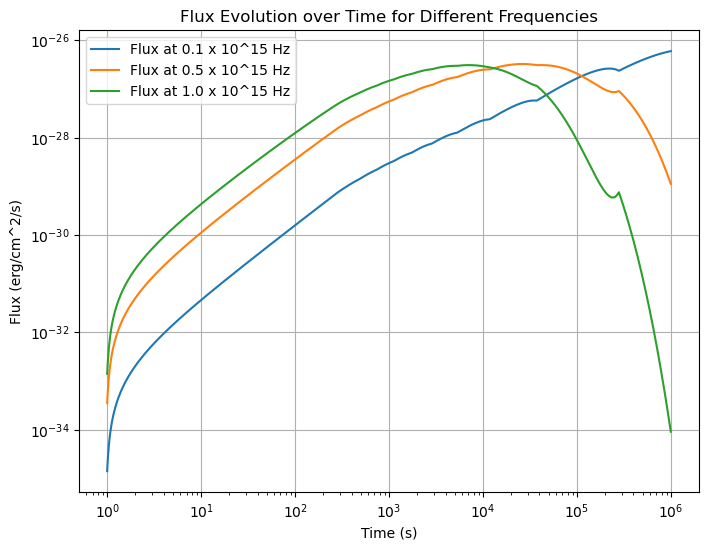

C:\Users\olibr\AppData\Local\Temp\ipykernel_22108\4053180193.py:42: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim([0, 1e6])


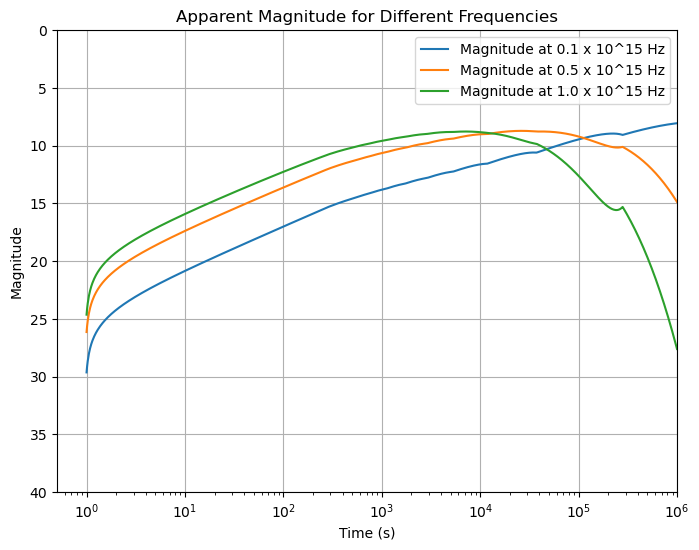

In [32]:
# Define frequency range (this can be changed based on what fluxes you want to explore)
nu_range = np.array([1e14, 5e14, 1e15])  # Example frequencies (in Hz)

# Compute fluxes for each frequency in nu_range
Flux_all = []
for nu in nu_range:
    T_eff = []
    for i in range(len(R_ph)):
        # Calculate the effective temperature for each shell
        T_eff_shell = (L_tot[i] / (4 * np.pi * sigma * (R_ph[i] ** 2))) ** (1 / 4)
        T_eff.append(T_eff_shell)

    # Calculate the flux for each shell at the given frequency
    Flux = []
    for i in range(len(T_eff)):
        Flux_shell = ((2 * np.pi * h * (nu ** 3)) / (c ** 2)) * (1 / (np.exp((h * nu) / (kB * T_eff[i])) - 1)) * (R_ph[i] ** 2 / D ** 2)
        Flux.append(Flux_shell)
    
    Flux_all.append(np.array(Flux))  # Store fluxes for this frequency

# Plotting the flux for different frequencies
plt.figure(figsize=(8, 6))
for i, nu in enumerate(nu_range):
    plt.loglog(t, Flux_all[i], label=f'Flux at {nu/1e15} x 10^15 Hz')

plt.xlabel('Time (s)')
plt.ylabel('Flux (erg/cm^2/s)')
plt.title('Flux Evolution over Time for Different Frequencies')
plt.grid(True)
plt.legend()
plt.show()

# Plotting the apparent magnitude for different frequencies
zero_point_flux = 1e-23  # Zero point flux in erg/cm^2/s/Hz
plt.figure(figsize=(8, 6))
for i, nu in enumerate(nu_range):
    total_magnitude = -2.5 * np.log10(Flux_all[i] / zero_point_flux)
    plt.plot(t, total_magnitude, label=f'Magnitude at {nu/1e15} x 10^15 Hz')

plt.xscale('log')
ax = plt.gca()
ax.set_xlim([0, 1e6])
ax.set_ylim([0, 40])
plt.xlabel('Time (s)')
plt.gca().invert_yaxis()  # Invert y-axis to match magnitude convention (lower is brighter)
plt.ylabel('Magnitude')
plt.legend()
plt.title('Apparent Magnitude for Different Frequencies')
plt.grid(True)
plt.show()